In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load Function 1 data
X = np.load("function1/initial_inputs.npy")
Y = np.load("function1/initial_outputs.npy")

# Fit GP surrogate model
kernel = C(1.0) * RBF(length_scale=0.2)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True, random_state=42)
gp.fit(X, Y)

# Generate random candidate points in 2D
num_candidates = 10000
candidates = np.random.uniform(0, 1, size=(num_candidates, X.shape[1]))

# Predict mean and uncertainty
mean, std = gp.predict(candidates, return_std=True)

# UCB acquisition function
kappa = 2.5
ucb = mean + kappa * std

# Pick best UCB candidate
best_candidate_index = np.argmax(ucb)
query = candidates[best_candidate_index]

print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[best_candidate_index])
print("Predicted std:", std[best_candidate_index])
print("UCB score:", ucb[best_candidate_index])

Suggested query: [0.81419684 0.26748016]
Portal format: 0.814197-0.267480
Predicted mean: -0.0003128979628412832
Predicted std: 0.0010723099794408386
UCB score: 0.0023678769857608133


In [2]:
#For Function 1, I changed from UCB to posterior variance acquisition because the outputs were very sparse and Week 1 did not improve the best value. Since there was no strong region to exploit yet,
#I prioritised exploration by selecting the point with the highest GP uncertainty. This was intended to gather more information about the search space rather than repeatedly testing around a weak signal.
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load original Function 1 data
X = np.load("function1/initial_inputs.npy")
Y = np.load("function1/initial_outputs.npy")

# Add Week 1 query and output
week1_x = np.array([[0.737954, 0.758348]])
week1_y = np.array([-2.857650951335033e-21])

X = np.vstack([X, week1_x])
Y = np.append(Y, week1_y)


print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

print("Best current x:", X[np.argmax(Y)])
print("Best current y:", np.max(Y))

# Fit GP surrogate model
kernel = C(1.0) * RBF(length_scale=0.2)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)

# Generate candidate points
rng = np.random.default_rng(42)
candidates = rng.uniform(0, 1, size=(10000, X.shape[1]))

# Predict mean and uncertainty
mean, std = gp.predict(candidates, return_std=True)

# Posterior variance acquisition function
variance = std ** 2

# Pick point with maximum posterior variance
best_var_index = np.argmax(variance)
query = candidates[best_var_index]

print("Acquisition used: Posterior variance")
print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[best_var_index])
print("Predicted std:", std[best_var_index])
print("Variance score:", variance[best_var_index])

Updated X shape: (11, 2)
Updated Y shape: (11,)
Best current x: [0.73102363 0.73299988]
Best current y: 7.710875114502849e-16
Acquisition used: Posterior variance
Suggested query: [0.77395605 0.43887844]
Portal format: 0.773956-0.438878
Predicted mean: -0.00032782387676024593
Predicted std: 0.0010366701220307754
Variance score: 1.0746849419113028e-06


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [3]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C


# -----------------------------
# Load original Function 1 data
# -----------------------------
X = np.load("function1/initial_inputs.npy")
Y = np.load("function1/initial_outputs.npy")


# -----------------------------
# Add Week 1 and Week 2 results
# -----------------------------

week2_x = np.array([[0.773956, 0.438878]])
week2_y = np.array([9.656222973626152e-41])

X = np.vstack([X, week2_x])
Y = np.append(Y, week2_y[0]])


print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Best current x:", best_x)
print("Best current y:", best_y)


# -----------------------------
# Fit GP surrogate model
# -----------------------------
# Matern is more flexible than RBF for black-box optimisation because it
# allows less perfectly smooth functions.
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(X.shape[1]) * 0.2, length_scale_bounds=(1e-2, 1.0), nu=2.5)
    + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-4))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)


# -----------------------------
# Generate candidate points
# -----------------------------
rng = np.random.default_rng(42)

dim = X.shape[1]

# Global exploration candidates across the full [0, 1]^d space
global_candidates = rng.uniform(0, 1, size=(15000, dim))

# Local exploitation candidates around the best known point
# This helps because Function 1 appears sparse, so completely random
# exploration may keep landing in near-zero regions.
local_candidates = rng.normal(loc=best_x, scale=0.08, size=(10000, dim))
local_candidates = np.clip(local_candidates, 0, 1)

# Combine both candidate pools
candidates = np.vstack([global_candidates, local_candidates])


# -----------------------------
# Predict mean and uncertainty
# -----------------------------
mean, std = gp.predict(candidates, return_std=True)


# -----------------------------
# Hybrid sparse-aware acquisition
# -----------------------------
# UCB balances predicted mean and uncertainty.
# A higher kappa keeps exploration important.
kappa = 2.5
ucb = mean + kappa * std

# Normalise acquisition components so they are comparable
ucb_norm = (ucb - np.min(ucb)) / (np.max(ucb) - np.min(ucb) + 1e-12)
std_norm = (std - np.min(std)) / (np.max(std) - np.min(std) + 1e-12)

# Since Week 2 pure variance did not improve the score,
# reduce reliance on uncertainty alone.
hybrid_score = 0.65 * ucb_norm + 0.35 * std_norm

best_candidate_index = np.argmax(hybrid_score)
query = candidates[best_candidate_index]


# -----------------------------
# Output results
# -----------------------------
print("Acquisition used: Sparse-aware hybrid UCB + posterior uncertainty")
print("Suggested query:", query)

print("Portal format with hyphens:")
print("-".join(f"{v:.6f}" for v in query))

print("Portal format with x labels:")
print(",".join(f"x{i+1}:{v:.6f}" for i, v in enumerate(query)))

print("Predicted mean:", mean[best_candidate_index])
print("Predicted std:", std[best_candidate_index])
print("UCB score:", ucb[best_candidate_index])
print("Hybrid score:", hybrid_score[best_candidate_index])

Updated X shape: (12, 2)
Updated Y shape: (12,)
Best current x: [0.73102363 0.73299988]
Best current y: 7.710875114502849e-16
Fitted kernel: 1.02**2 * Matern(length_scale=[1, 0.0274], nu=2.5) + WhiteKernel(noise_level=1.3e-08)
Acquisition used: Sparse-aware hybrid UCB + posterior uncertainty
Suggested query: [0.36065733 0.51273924]
Portal format with hyphens:
0.360657-0.512739
Portal format with x labels:
x1:0.360657,x2:0.512739
Predicted mean: -0.0002712322639030833
Predicted std: 0.0010103170139138208
UCB score: 0.002254560270881469
Hybrid score: 0.9979291942080704


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
# Local exploitation candidates around the best known point
rng = np.random.default_rng(42)
dim = X.shape[1]

local_candidates = rng.normal(loc=best_x, scale=0.04, size=(20000, dim))
local_candidates = np.clip(local_candidates, 0, 1)

mean, std = gp.predict(local_candidates, return_std=True)

# Use UCB locally, not globally
kappa = 1.5
ucb = mean + kappa * std

best_candidate_index = np.argmax(ucb)
query = local_candidates[best_candidate_index]

print("Acquisition used: Local UCB around current best point")
print("Suggested query:", query)
print("Portal format with hyphens:")
print("-".join(f"{v:.6f}" for v in query))
print("Portal format with x labels:")
print(",".join(f"x{i+1}:{v:.6f}" for i, v in enumerate(query)))
print("Predicted mean:", mean[best_candidate_index])
print("Predicted std:", std[best_candidate_index])
print("UCB score:", ucb[best_candidate_index])

Acquisition used: Local UCB around current best point
Suggested query: [0.67658295 0.81194073]
Portal format with hyphens:
0.676583-0.811941
Portal format with x labels:
x1:0.676583,x2:0.811941
Predicted mean: -0.00022846479460713552
Predicted std: 0.0009720178506192641
UCB score: 0.0012295619813217605


In [8]:
from scipy.stats import norm

week3_x = np.array([[0.676583, 0.811941]])
week3_y = np.array([-3.592807837147156e-26])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x
])

Y = np.append(Y, [
    week1_y[0],
    week2_y[0],
    week3_y[0]
])

print("X shape:", X.shape)
print("Y shape:", Y.shape)


# -----------------------------
# Transform outputs
# Higher score = closer to zero
# -----------------------------
epsilon = 1e-50
Y_score = -np.log10(np.abs(Y) + epsilon)

best_index = np.argmax(Y_score)
best_x = X[best_index]

print("Best current x:", best_x)
print("Best original y:", Y[best_index])
print("Best transformed score:", Y_score[best_index])


# -----------------------------
# Fit the GP
# -----------------------------
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(X.shape[1]) * 0.2,
        length_scale_bounds=(1e-2, 1.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=15,
    random_state=44
)

gp.fit(X, Y_score)

print("Fitted kernel:", gp.kernel_)


# -----------------------------
# Generate multi-scale candidates
# -----------------------------
rng = np.random.default_rng(44)
dim = X.shape[1]

very_local = rng.normal(
    loc=best_x,
    scale=0.01,
    size=(10000, dim)
)

local = rng.normal(
    loc=best_x,
    scale=0.04,
    size=(15000, dim)
)

wider_local = rng.normal(
    loc=best_x,
    scale=0.10,
    size=(10000, dim)
)

global_candidates = rng.uniform(
    0,
    1,
    size=(10000, dim)
)

candidates = np.vstack([
    very_local,
    local,
    wider_local,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)


# -----------------------------
# Avoid repeating observations
# -----------------------------
distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)
candidates = candidates[minimum_distance > 0.005]


# -----------------------------
# Expected Improvement
# -----------------------------
mean, std = gp.predict(candidates, return_std=True)

best_score = np.max(Y_score)
xi = 0.01

improvement = mean - best_score - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std
    ei = improvement * norm.cdf(z) + std * norm.pdf(z)

ei[std == 0] = 0

best_candidate_index = np.argmax(ei)
query = candidates[best_candidate_index]


# -----------------------------
# Results
# -----------------------------
print("Acquisition used: Expected Improvement on log-closeness score")
print("Suggested Week 4 query:", query)

print("Portal format:")
print("-".join(f"{value:.6f}" for value in query))

print("Predicted transformed score:", mean[best_candidate_index])
print("Predicted uncertainty:", std[best_candidate_index])
print("Expected Improvement:", ei[best_candidate_index])

X shape: (24, 2)
Y shape: (24,)
Best current x: [0.31940389 0.76295937]
Best original y: 1.3226770395454077e-79
Best transformed score: 50.0


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/

Fitted kernel: 1.45**2 * Matern(length_scale=[0.212, 0.215], nu=2.5) + WhiteKernel(noise_level=1e-10)
Acquisition used: Expected Improvement on log-closeness score
Suggested Week 4 query: [0.61509699 1.        ]
Portal format:
0.615097-1.000000
Predicted transformed score: 57.319181416247325
Predicted uncertainty: 10.062613165726058
Expected Improvement: 8.68380145078918


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
import matplotlib.pyplot as plt

# -----------------------------
# Create a regular 2D grid
# -----------------------------
grid_size = 150

x1_values = np.linspace(0, 1, grid_size)
x2_values = np.linspace(0, 1, grid_size)

X1_grid, X2_grid = np.meshgrid(x1_values, x2_values)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])


# -----------------------------
# GP predictions across the grid
# -----------------------------
grid_mean, grid_std = gp.predict(
    grid_points,
    return_std=True
)

grid_mean = grid_mean.reshape(X1_grid.shape)
grid_std = grid_std.reshape(X1_grid.shape)


# Expected Improvement across the grid
best_score = np.max(Y_score)
xi = 0.01

grid_improvement = grid_mean - best_score - xi

with np.errstate(divide="ignore", invalid="ignore"):
    grid_z = grid_improvement / grid_std

    grid_ei = (
        grid_improvement * norm.cdf(grid_z)
        + grid_std * norm.pdf(grid_z)
    )

grid_ei[grid_std == 0] = 0

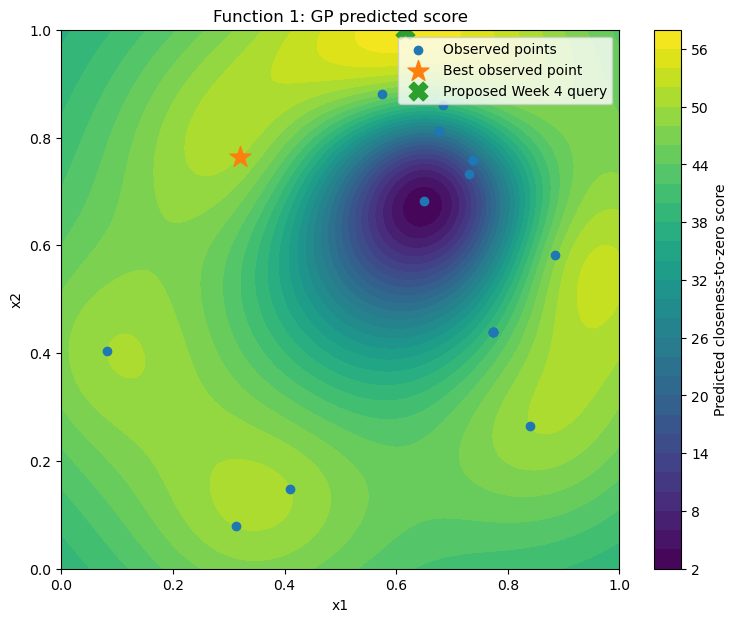

In [10]:
plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_mean,
    levels=30
)

plt.colorbar(
    contour,
    label="Predicted closeness-to-zero score"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    label="Observed points"
)

plt.scatter(
    best_x[0],
    best_x[1],
    marker="*",
    s=250,
    label="Best observed point"
)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    s=180,
    label="Proposed Week 4 query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: GP predicted score")
plt.legend()
plt.show()

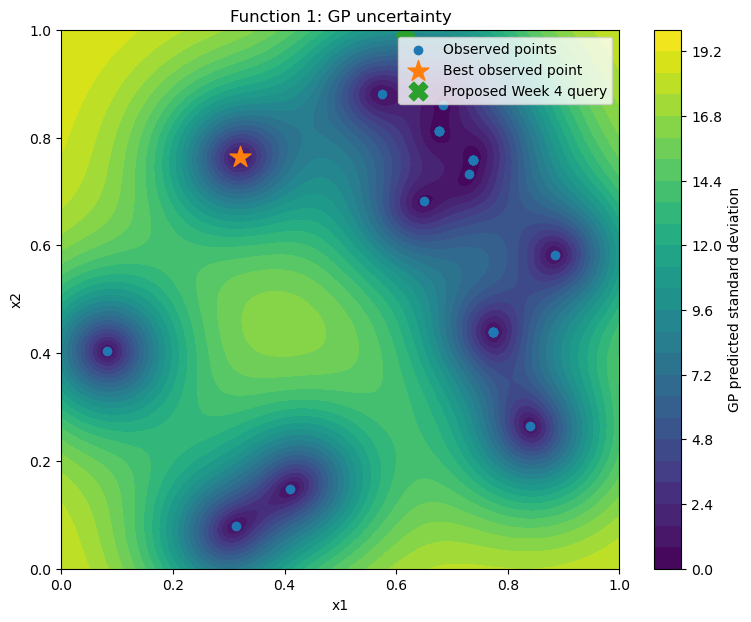

In [11]:
plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_std,
    levels=30
)

plt.colorbar(
    contour,
    label="GP predicted standard deviation"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    label="Observed points"
)

plt.scatter(
    best_x[0],
    best_x[1],
    marker="*",
    s=250,
    label="Best observed point"
)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    s=180,
    label="Proposed Week 4 query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: GP uncertainty")
plt.legend()
plt.show()

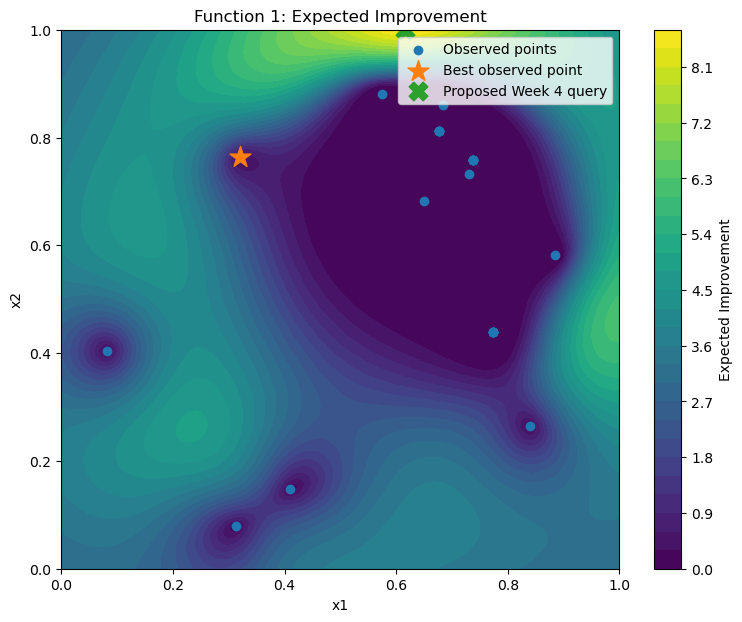

In [12]:
plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_ei,
    levels=30
)

plt.colorbar(
    contour,
    label="Expected Improvement"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    label="Observed points"
)

plt.scatter(
    best_x[0],
    best_x[1],
    marker="*",
    s=250,
    label="Best observed point"
)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    s=180,
    label="Proposed Week 4 query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: Expected Improvement")
plt.legend()
plt.show()


In [13]:
print("Predicted mean:", mean[best_candidate_index])
print("Predicted std:", std[best_candidate_index])
print("Distance to nearest observation:", minimum_distance[best_candidate_index])

Predicted mean: 57.319181416247325
Predicted std: 10.062613165726058
Distance to nearest observation: 0.13297145339530325
